# RAF-DB Facial Emotion Recognition — Model Analysis (DDAMFN)

Stress-tests the fine-tuned **DDAMFN** model (91.07% on the RAF-DB test set) beyond a single accuracy number:

1. **Robustness** — accuracy under blur, low light, sensor noise, JPEG compression and low resolution
2. **Occlusion** — sunglasses vs. face mask: *which facial region does each emotion depend on?*
3. **Test-time augmentation** — horizontal-flip averaging
4. **Calibration** — are the confidence scores trustworthy? (ECE + temperature scaling fit on validation)
5. **Failure analysis** — the most confident mistakes
6. **Embedding space** — t-SNE of the learned 512-d features
7. **Where the model looks** — average Grad-CAM per emotion

**Inputs:** the RAF-DB dataset (`train_labels.csv`, `test_labels.csv`, images) and the trained checkpoint
`ddamfn_rafdb_final.pth`. No training — runs in a few minutes on GPU (also works on CPU).

## 0 · Model code (DDAMFN — MixedFeatureNet backbone + dual-direction attention)

In [2]:
%%writefile MixedFeatureNet.py

from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Sequential, Module
import torch
import torch.nn as nn
class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

def l2_norm(input,axis=1):
    norm = torch.norm(input,2,axis,True)
    output = torch.div(input, norm)
    return output

class Conv_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Conv_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
        self.prelu = PReLU(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.prelu(x)
        return x

class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1):
        super(Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = Conv_block(groups, groups, groups=groups, kernel=kernel, padding=padding, stride=stride)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
  

class Swish(nn.Module):
    def __init__(self):
        super(Swish, self).__init__()

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(x)

NON_LINEARITY = {
    'ReLU': nn.ReLU(inplace=True),
    'Swish': Swish(),
}        


class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)
    
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)

        y = identity * x_w * x_h

        return y

        
class MDConv(Module):
    def __init__(self, channels, kernel_size, split_out_channels, stride):
        super(MDConv, self).__init__()
        self.num_groups = len(kernel_size)
        self.split_channels = split_out_channels
        self.mixed_depthwise_conv = nn.ModuleList()
        for i in range(self.num_groups):
            self.mixed_depthwise_conv.append(Conv2d(
                self.split_channels[i],
                self.split_channels[i],
                kernel_size[i],
                stride=stride,
                padding=kernel_size[i]//2,
                groups=self.split_channels[i],
                bias=False
            ))
        self.bn = BatchNorm2d(channels)
        self.prelu = PReLU(channels)            
       
    def forward(self, x):
        if self.num_groups == 1:
            return self.mixed_depthwise_conv[0](x)

        x_split = torch.split(x, self.split_channels, dim=1)
        x = [conv(t) for conv, t in zip(self.mixed_depthwise_conv, x_split)]
        x = torch.cat(x, dim=1)

        return x        
      
        
class Mix_Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1, kernel_size=[3,5,7], split_out_channels=[64,32,32]):
        super(Mix_Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = MDConv(channels=groups, kernel_size=kernel_size, split_out_channels=split_out_channels, stride=stride)
        self.CA = CoordAtt(groups, groups)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.CA(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
          
class Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1)):
        super(Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        
class Mix_Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[64,64]):
        super(Mix_Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Mix_Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups, kernel_size=kernel_size, split_out_channels=split_out_channels ))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        

class MixedFeatureNet(Module):
    def __init__(self, embedding_size=256, out_h=7, out_w=7):
        super(MixedFeatureNet, self).__init__()
        #112x112
        self.conv1 = Conv_block(3, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1))
        #56x56
        self.conv2_dw = Conv_block(64, 64, kernel=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        self.conv_23 = Mix_Depth_Wise(64, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=128, kernel_size=[3,5,7], split_out_channels=[64,32,32] )
        
        #28x28
        self.conv_3 = Mix_Residual(64, num_block=9, groups=128, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[96,32])
        self.conv_34 = Mix_Depth_Wise(64, 128, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=256, kernel_size=[3,5,7],split_out_channels=[128,64,64] )
        
        #14x14
        self.conv_4 = Mix_Residual(128, num_block=16, groups=256, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[192,64])
        self.conv_45 = Mix_Depth_Wise(128, 256, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=512*2, kernel_size=[3,5,7,9],split_out_channels=[128*2,128*2,128*2,128*2] )
        #7x7
        self.conv_5 = Mix_Residual(256, num_block=6, groups=512, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5,7], split_out_channels=[86*2,85*2,85*2])                
        self.conv_6_sep = Conv_block(256, 512, kernel=(1, 1), stride=(1, 1), padding=(0, 0))
        self.conv_6_dw = Linear_block(512, 512, groups=512, kernel=(out_h, out_w), stride=(1, 1), padding=(0, 0))
        self.conv_6_flatten = Flatten()
        self.linear = Linear(512, embedding_size, bias=False)
        self.bn = BatchNorm1d(embedding_size)
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2_dw(out)
        out = self.conv_23(out)
        out = self.conv_3(out)
        out = self.conv_34(out)
        out = self.conv_4(out)
        out = self.conv_45(out)
        out = self.conv_5(out)
        out = self.conv_6_sep(out)
        out = self.conv_6_dw(out)
        out = self.conv_6_flatten(out)
        out = self.linear(out)
        out = self.bn(out)

        return l2_norm(out)

Writing MixedFeatureNet.py


In [3]:
%%writefile DDAM.py
from torch import nn
import torch
import MixedFeatureNet
from torch.nn import Module
import os
class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = nn.Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)
        
class DDAMNet(nn.Module):
    def __init__(self, num_class=7,num_head=2, pretrained=True):
        super(DDAMNet, self).__init__()

        net = MixedFeatureNet.MixedFeatureNet()
                
        if pretrained:
            net = torch.load(os.path.join('./pretrained/', "MFN_msceleb.pth"))       
      
        self.features = nn.Sequential(*list(net.children())[:-4])
        self.num_head = num_head
        for i in range(int(num_head)):
            setattr(self,"cat_head%d" %(i), CoordAttHead())                  
      
        self.Linear = Linear_block(512, 512, groups=512, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten()      
        self.fc = nn.Linear(512, num_class)
        self.bn = nn.BatchNorm1d(num_class)
        
    def forward(self, x):
        x = self.features(x)
        heads = []
       
        for i in range(self.num_head):
            heads.append(getattr(self,"cat_head%d" %i)(x))
        head_out =heads
        
        y = heads[0]
        
        for i in range(1,self.num_head):
            y = torch.max(y,heads[i])                     
        
        y = x*y
        y = self.Linear(y)
        y = self.flatten(y) 
        out = self.fc(y)        
        return out, x, head_out
        
class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)
    def forward(self, x):
        return self.relu(x + 3) / 6
                      
class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)
    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAttHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.CoordAtt = CoordAtt(512,512)
    def forward(self, x):
        ca = self.CoordAtt(x)
        return ca  
        
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
      
        self.Linear_h = Linear_block(inp, inp, groups=inp, kernel=(1, 7), stride=(1, 1), padding=(0, 0))        
        self.Linear_w = Linear_block(inp, inp, groups=inp, kernel=(7, 1), stride=(1, 1), padding=(0, 0))
        
        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()
        self.Linear = Linear_block(oup, oup, groups=oup, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten() 

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.Linear_h(x)
        x_w = self.Linear_w(x)
        x_w = x_w.permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)
        
        y = x_w * x_h
 
        return y

Writing DDAM.py


## 1 · Setup — data, checkpoint, clean test evaluation

In [5]:
import os, sys, json, io, random, numpy as np, pandas as pd, torch, torch.nn.functional as F, cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
sys.path.insert(0, os.getcwd())
from DDAM import DDAMNet

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DATA = os.environ.get('DATA_ROOT', '/kaggle/input')
OUT  = os.environ.get('OUT_ROOT', '/kaggle/working')
FIG  = os.path.join(OUT, 'figs'); os.makedirs(FIG, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
S = 112
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
EMO_HEX = {'Happiness': '#22c55e', 'Surprise': '#06b6d4', 'Neutral': '#94a3b8', 'Sadness': '#3b82f6',
           'Fear': '#a855f7', 'Disgust': '#eab308', 'Anger': '#ef4444'}
COLORS = [EMO_HEX[c] for c in CLASS_NAMES]
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
def save(fig, name):
    fig.savefig(os.path.join(FIG, name), bbox_inches='tight', facecolor='white'); plt.show()

train_csv = test_csv = ckpt_path = None; IMG = {}
for root, _, files in os.walk(DATA):
    for f in files:
        if   f == 'train_labels.csv': train_csv = os.path.join(root, f)
        elif f == 'test_labels.csv':  test_csv  = os.path.join(root, f)
        elif f in ('ddamfn_rafdb_final.pth', 'ddamfn_rafdb_best.pth'): ckpt_path = os.path.join(root, f)
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')): IMG[f] = os.path.join(root, f)
assert train_csv and test_csv, 'RAF-DB CSVs not found - add the RAF-DB dataset as an input'
assert ckpt_path, 'ddamfn_rafdb_final.pth not found - add the checkpoint dataset as an input'
print('images indexed:', len(IMG), '| checkpoint:', ckpt_path, '| device:', DEVICE)

model = DDAMNet(num_class=7, num_head=2, pretrained=False).to(DEVICE).eval()
ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck.get('model_state_dict', ck))

def load_split(df):
    X = np.stack([np.array(Image.open(IMG[n]).convert('RGB').resize((S, S), Image.BILINEAR)) for n in df['image']])
    return X, df['label'].to_numpy() - 1                     # CSV 1..7 -> 0..6

test_df = pd.read_csv(test_csv)
train_full = pd.read_csv(train_csv)
_, val_df = train_test_split(train_full, test_size=0.10, stratify=train_full['label'], random_state=SEED)
Xte, yte = load_split(test_df); Xva, yva = load_split(val_df)
print('test', Xte.shape, '| val', Xva.shape)

MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)
def to_tensor(X):
    return (torch.from_numpy(X).to(DEVICE).permute(0, 3, 1, 2).float() / 255 - MEAN) / STD

_feat = {}
model.fc.register_forward_hook(lambda m, i, o: _feat.__setitem__('f', i[0].detach()))

@torch.no_grad()
def predict(X, bs=256, flip_tta=False, feats=False):
    L, Fs = [], []
    for i in range(0, len(X), bs):
        x = to_tensor(X[i:i + bs]); out, _, _ = model(x)
        if feats: Fs.append(_feat['f'].cpu())
        if flip_tta: out = (out + model(torch.flip(x, dims=[3]))[0]) / 2
        L.append(out.cpu())
    L = torch.cat(L).numpy()
    return (L, torch.cat(Fs).numpy()) if feats else L

def scores(logits, y):
    p = logits.argmax(1); return 100 * (p == y).mean(), 100 * balanced_accuracy_score(y, p)

logits_te, feats_te = predict(Xte, feats=True)
clean_acc, clean_bacc = scores(logits_te, yte)
print(f'CLEAN test: overall {clean_acc:.2f}% | mean-class {clean_bacc:.2f}%')

images indexed: 15339 | checkpoint: /kaggle/input/datasets/hridyeshkumar/raf-db-final/ddamfn_rafdb_final.pth | device: cuda
test (3068, 112, 112, 3) | val (1228, 112, 112, 3)
CLEAN test: overall 91.07% | mean-class 84.64%


## 2 · Robustness to real-world image degradations
Each corruption is applied to every test image at three severities; the model is **not** retrained.

Gaussian blur       89.44%   81.75%   71.12%
Low light           90.35%   89.02%   83.44%
Sensor noise        90.22%   85.92%   76.50%
JPEG compression    90.38%   89.05%   81.88%
Low resolution      89.57%   83.21%   70.73%


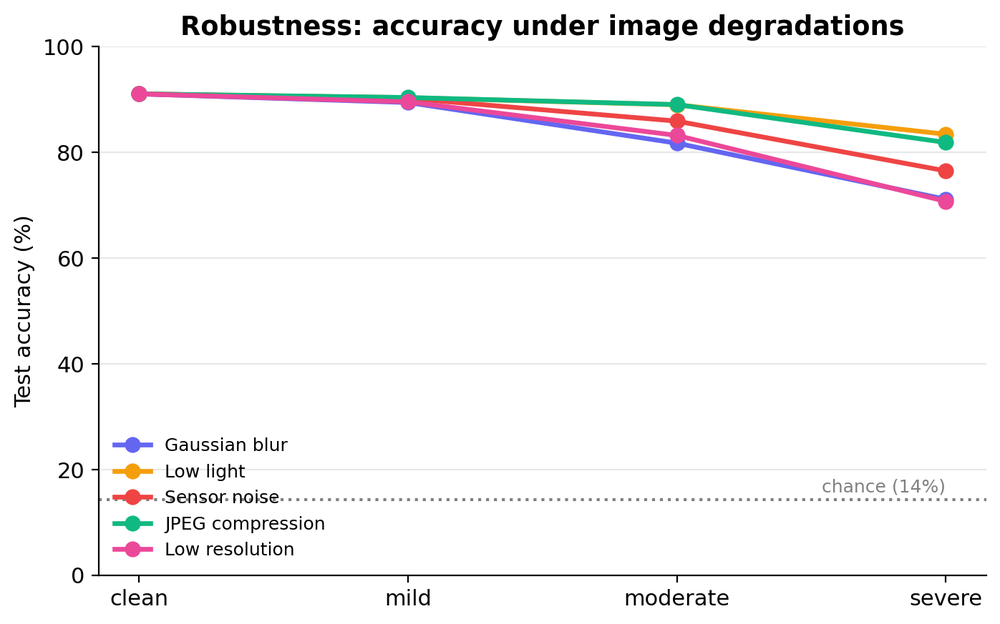

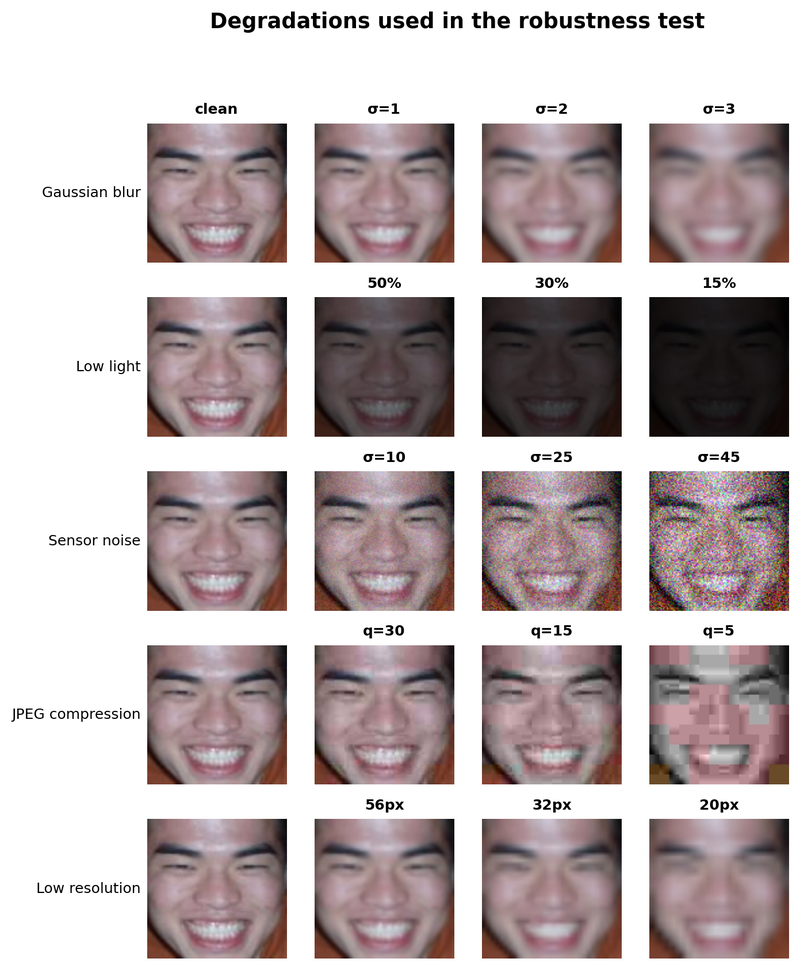

In [7]:
def blur(X, s):    return np.stack([cv2.GaussianBlur(x, (0, 0), s) for x in X])
def dark(X, f):    return np.clip(X.astype(np.float32) * f, 0, 255).astype(np.uint8)
def noise(X, s):   return np.clip(X + np.random.default_rng(0).normal(0, s, X.shape), 0, 255).astype(np.uint8)
def jpeg(X, q):    return np.stack([cv2.imdecode(cv2.imencode('.jpg', x, [cv2.IMWRITE_JPEG_QUALITY, q])[1], 1) for x in X])
def lowres(X, r):  return np.stack([cv2.resize(cv2.resize(x, (r, r), interpolation=cv2.INTER_AREA), (S, S)) for x in X])

CORRUPTIONS = {
    'Gaussian blur':    (blur,   [1.0, 2.0, 3.0],  ['σ=1', 'σ=2', 'σ=3']),
    'Low light':        (dark,   [0.5, 0.3, 0.15], ['50%', '30%', '15%']),
    'Sensor noise':     (noise,  [10, 25, 45],     ['σ=10', 'σ=25', 'σ=45']),
    'JPEG compression': (jpeg,   [30, 15, 5],      ['q=30', 'q=15', 'q=5']),
    'Low resolution':   (lowres, [56, 32, 20],     ['56px', '32px', '20px']),
}
robust = {'Clean': {'acc': [clean_acc], 'bacc': [clean_bacc]}}
for name, (fn, levels, _) in CORRUPTIONS.items():
    robust[name] = {'acc': [], 'bacc': []}
    for lv in levels:
        a, b = scores(predict(fn(Xte, lv)), yte)
        robust[name]['acc'].append(a); robust[name]['bacc'].append(b)
    print(f"{name:18s}", '  '.join(f"{a:6.2f}%" for a in robust[name]['acc']))

# --- figure: accuracy vs severity
fig, ax = plt.subplots(figsize=(8, 4.8))
pal = ['#6366f1', '#f59e0b', '#ef4444', '#10b981', '#ec4899']
for (name, (_, _, lab)), c in zip(CORRUPTIONS.items(), pal):
    ax.plot([0, 1, 2, 3], [clean_acc] + robust[name]['acc'], 'o-', lw=2.4, ms=7, color=c, label=name)
ax.set_xticks([0, 1, 2, 3]); ax.set_xticklabels(['clean', 'mild', 'moderate', 'severe'])
ax.set_ylabel('Test accuracy (%)'); ax.set_ylim(0, 100); ax.grid(axis='y', alpha=.3)
ax.axhline(100 / 7, ls=':', color='grey'); ax.text(3, 100 / 7 + 1.5, 'chance (14%)', ha='right', color='grey', fontsize=9)
ax.set_title('Robustness: accuracy under image degradations'); ax.legend(frameon=False, fontsize=9, loc='lower left')
save(fig, 'robustness_curves.png')

# --- figure: what each corruption looks like (one test face)
idx = int(np.where(yte == CLASS_NAMES.index('Happiness'))[0][3])
x0 = Xte[idx:idx + 1]
fig, axs = plt.subplots(len(CORRUPTIONS), 4, figsize=(7.2, 1.9 * len(CORRUPTIONS)))
for r, (name, (fn, levels, labs)) in enumerate(CORRUPTIONS.items()):
    axs[r, 0].imshow(x0[0]); axs[r, 0].set_ylabel(name, fontsize=9, rotation=0, ha='right', va='center')
    axs[r, 0].set_title('clean' if r == 0 else '', fontsize=9)
    for c, (lv, lb) in enumerate(zip(levels, labs), 1):
        axs[r, c].imshow(fn(x0, lv)[0]); axs[r, c].set_title(lb, fontsize=9)
for a in axs.flat: a.set_xticks([]); a.set_yticks([]); [s.set_visible(False) for s in a.spines.values()]
fig.suptitle('Degradations used in the robustness test', fontweight='bold'); save(fig, 'robustness_examples.png')

## 3 · Occlusion — what does each emotion need to see?
RAF-DB faces are aligned, so the eye and mouth regions sit at roughly fixed positions. We simulate
**sunglasses** (eyes + brows covered) and a **face mask** (nose + mouth covered) and measure per-class recall.

Clean                        overall  91.07% | Surp  88.1 Fear  67.6 Disg  73.8 Happ  97.0 Sadn  88.1 Ange  85.8 Neut  92.1
Sunglasses (eyes covered)    overall  85.10% | Surp  75.7 Fear  44.6 Disg  48.8 Happ  95.4 Sadn  79.5 Ange  75.9 Neut  90.7
Face mask (mouth covered)    overall  74.80% | Surp  64.7 Fear  27.0 Disg  27.5 Happ  79.0 Sadn  86.2 Ange  71.6 Neut  81.5


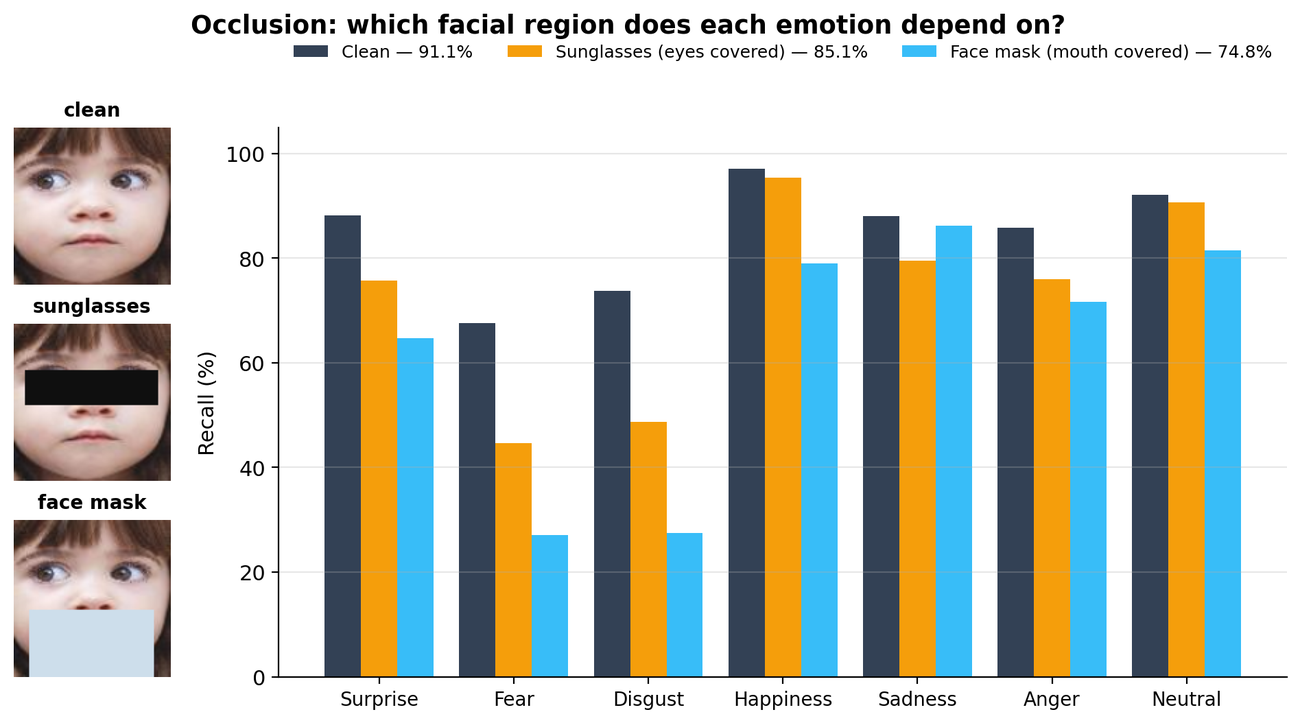

In [9]:
def sunglasses(X):
    X = X.copy(); X[:, int(.30 * S):int(.52 * S), int(.08 * S):int(.92 * S)] = 15; return X
def mask(X):
    X = X.copy(); X[:, int(.58 * S):, int(.10 * S):int(.90 * S)] = (205, 222, 235); return X

occl = {'Clean': logits_te.argmax(1), 'Sunglasses (eyes covered)': predict(sunglasses(Xte)).argmax(1),
        'Face mask (mouth covered)': predict(mask(Xte)).argmax(1)}
recall = {k: [100 * (p[yte == c] == c).mean() for c in range(7)] for k, p in occl.items()}
occl_acc = {k: 100 * (p == yte).mean() for k, p in occl.items()}
for k in occl: print(f"{k:28s} overall {occl_acc[k]:6.2f}% | " + ' '.join(f"{CLASS_NAMES[c][:4]} {recall[k][c]:5.1f}" for c in range(7)))

fig = plt.figure(figsize=(12, 5.2)); gs = fig.add_gridspec(3, 2, width_ratios=[1, 6.2], wspace=.18, hspace=.25)
ex = Xte[int(np.where(yte == CLASS_NAMES.index('Surprise'))[0][0])][None]
for j, (t, X) in enumerate([('clean', ex), ('sunglasses', sunglasses(ex)), ('face mask', mask(ex))]):
    a = fig.add_subplot(gs[j, 0]); a.imshow(X[0]); a.set_title(t, fontsize=10); a.axis('off')
a = fig.add_subplot(gs[:, 1]); w = .27; xs = np.arange(7)
for k, (name, col) in enumerate(zip(occl, ['#334155', '#f59e0b', '#38bdf8'])):
    a.bar(xs + (k - 1) * w, recall[name], w, color=col, label=f"{name} — {occl_acc[name]:.1f}%")
a.set_xticks(xs); a.set_xticklabels(CLASS_NAMES, fontsize=10); a.set_ylabel('Recall (%)'); a.set_ylim(0, 105)
a.legend(frameon=False, fontsize=9, loc='upper center', bbox_to_anchor=(.5, 1.18), ncol=3); a.grid(axis='y', alpha=.3)
fig.suptitle('Occlusion: which facial region does each emotion depend on?', fontweight='bold', y=1.04)
save(fig, 'occlusion_per_class.png')

## 4 · Test-time augmentation (horizontal-flip averaging)

In [11]:
logits_tta = predict(Xte, flip_tta=True)
tta_acc, tta_bacc = scores(logits_tta, yte)
print(f'single view : {clean_acc:.2f}% overall | {clean_bacc:.2f}% mean-class')
print(f'flip TTA    : {tta_acc:.2f}% overall | {tta_bacc:.2f}% mean-class   ({tta_acc - clean_acc:+.2f} pts)')

single view : 91.07% overall | 84.64% mean-class
flip TTA    : 91.10% overall | 84.83% mean-class   (+0.03 pts)


## 5 · Calibration — can we trust the confidence scores?
**Expected Calibration Error (ECE)**: the gap between how confident the model says it is and how often it is right.
A single **temperature** is fitted on the *validation* split (never the test set) and then applied to test.

temperature (fit on val) T = 1.552
test ECE before 3.80%  ->  after 1.40%   (accuracy unchanged: 91.07%)


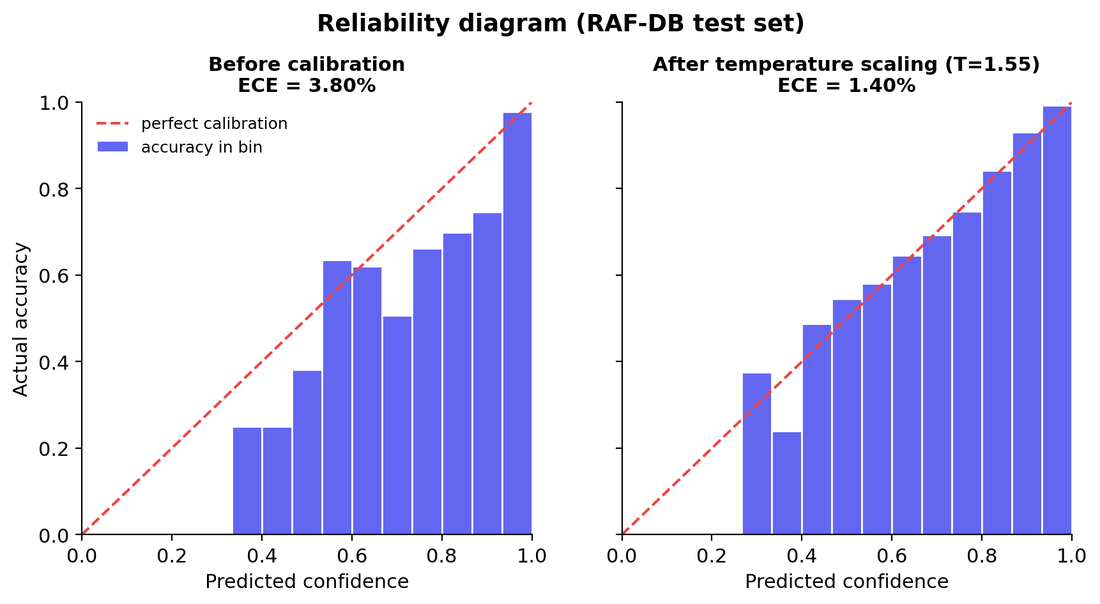

In [13]:
def ece(probs, y, n_bins=15):
    conf, pred = probs.max(1), probs.argmax(1); bins = np.linspace(0, 1, n_bins + 1); e = 0; rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            acc, cf = (pred[m] == y[m]).mean(), conf[m].mean(); e += m.mean() * abs(acc - cf); rows.append((lo, hi, acc, cf, m.sum()))
        else: rows.append((lo, hi, np.nan, np.nan, 0))
    return 100 * e, rows
softmax = lambda z: np.exp(z - z.max(1, keepdims=True)) / np.exp(z - z.max(1, keepdims=True)).sum(1, keepdims=True)

logits_va = predict(Xva)
T = torch.ones(1, requires_grad=True)
opt = torch.optim.LBFGS([T], lr=0.05, max_iter=200)
lv, yv = torch.from_numpy(logits_va).float(), torch.from_numpy(yva).long()
def closure():
    opt.zero_grad(); l = F.cross_entropy(lv / T, yv); l.backward(); return l
opt.step(closure); T = float(T.item())

ece_before, rows_b = ece(softmax(logits_te), yte); ece_after, rows_a = ece(softmax(logits_te / T), yte)
print(f'temperature (fit on val) T = {T:.3f}')
print(f'test ECE before {ece_before:.2f}%  ->  after {ece_after:.2f}%   (accuracy unchanged: {clean_acc:.2f}%)')

fig, axs = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
for a, rows, title, e in [(axs[0], rows_b, 'Before calibration', ece_before), (axs[1], rows_a, f'After temperature scaling (T={T:.2f})', ece_after)]:
    mids = [(lo + hi) / 2 for lo, hi, *_ in rows]; accs = [r[2] for r in rows]
    a.bar(mids, accs, width=1 / 15, edgecolor='white', color='#6366f1', label='accuracy in bin')
    a.plot([0, 1], [0, 1], '--', color='#ef4444', label='perfect calibration')
    a.set_title(f'{title}\nECE = {e:.2f}%', fontsize=11); a.set_xlabel('Predicted confidence'); a.set_xlim(0, 1); a.set_ylim(0, 1)
axs[0].set_ylabel('Actual accuracy'); axs[0].legend(frameon=False, fontsize=9, loc='upper left')
fig.suptitle('Reliability diagram (RAF-DB test set)', fontweight='bold', y=1.04); save(fig, 'calibration.png')

## 6 · Failure analysis — the model's most confident mistakes

Most frequent confusions (true -> predicted):
  Sadness   -> Neutral    34 images
  Neutral   -> Sadness    23 images
  Happiness -> Neutral    21 images
  Surprise  -> Neutral    14 images
  Disgust   -> Neutral    13 images
  Neutral   -> Surprise   11 images


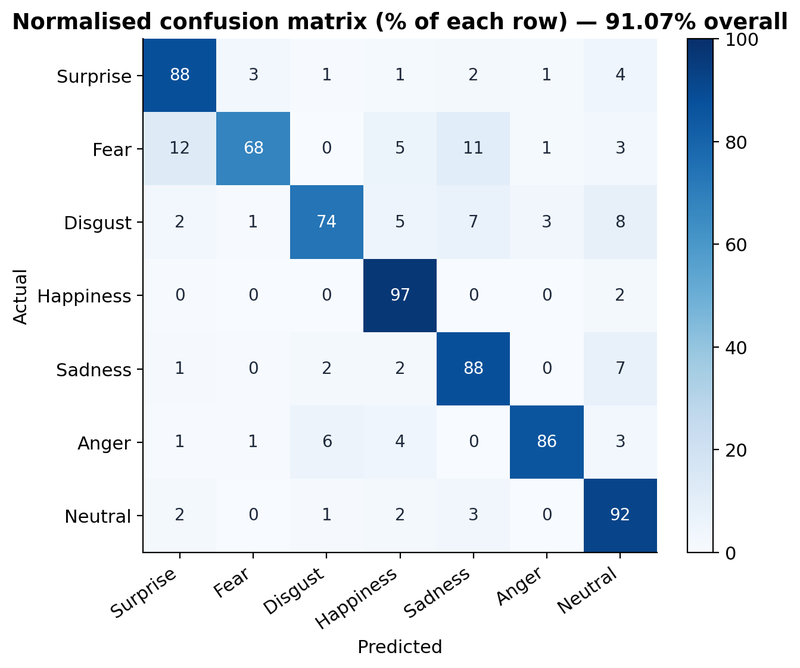

In [15]:
P = softmax(logits_te); pred = P.argmax(1); wrong = np.where(pred != yte)[0]
top = wrong[np.argsort(-P[wrong, pred[wrong]])][:16]
fig, axs = plt.subplots(2, 8, figsize=(16, 4.9))
for a, i in zip(axs.flat, top):
    a.imshow(Xte[i]); a.axis('off')
    a.set_title(f"true: {CLASS_NAMES[yte[i]]}\npred: {CLASS_NAMES[pred[i]]} ({P[i, pred[i]]:.0%})", fontsize=9,
                color=EMO_HEX[CLASS_NAMES[pred[i]]])
fig.suptitle('Most confident mistakes — many are genuinely ambiguous or arguably mislabelled', fontweight='bold')
save(fig, 'failure_gallery.png')

cm = confusion_matrix(yte, pred); off = [(cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]) for i in range(7) for j in range(7) if i != j]
print('Most frequent confusions (true -> predicted):')
for n, t, p_ in sorted(off, reverse=True)[:6]: print(f'  {t:9s} -> {p_:9s} {n:3d} images')

cmn = cm / cm.sum(1, keepdims=True) * 100
fig, a = plt.subplots(figsize=(6.6, 5.6)); im = a.imshow(cmn, cmap='Blues', vmin=0, vmax=100)
for i in range(7):
    for j in range(7): a.text(j, i, f"{cmn[i, j]:.0f}", ha='center', va='center', fontsize=10, color='white' if cmn[i, j] > 55 else '#1e293b')
a.set_xticks(range(7)); a.set_yticks(range(7)); a.set_xticklabels(CLASS_NAMES, rotation=35, ha='right'); a.set_yticklabels(CLASS_NAMES)
a.set_xlabel('Predicted'); a.set_ylabel('Actual'); a.set_title(f'Normalised confusion matrix (% of each row) — {clean_acc:.2f}% overall')
plt.colorbar(im, fraction=.046); save(fig, 'confusion_normalized.png')

## 7 · What has the model learned? — t-SNE of the 512-d face embeddings

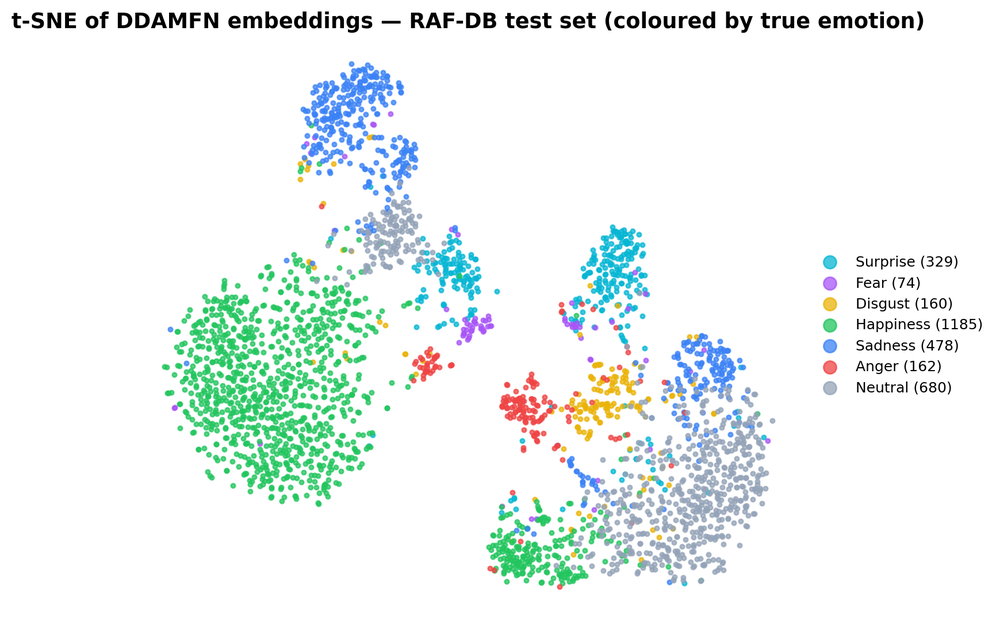

In [17]:
from sklearn.manifold import TSNE
Z = TSNE(n_components=2, perplexity=35, init='pca', random_state=SEED).fit_transform(feats_te)
fig, a = plt.subplots(figsize=(7.5, 6.5))
for c in range(7):
    m = yte == c; a.scatter(Z[m, 0], Z[m, 1], s=7, alpha=.75, color=COLORS[c], label=f'{CLASS_NAMES[c]} ({m.sum()})')
a.set_xticks([]); a.set_yticks([]); [s.set_visible(False) for s in a.spines.values()]
a.legend(frameon=False, markerscale=3, fontsize=9, loc='center left', bbox_to_anchor=(1, .5))
a.set_title('t-SNE of DDAMFN embeddings — RAF-DB test set (coloured by true emotion)'); save(fig, 'tsne_embeddings.png')

## 8 · Where does the model look? — average Grad-CAM per emotion (correct predictions)

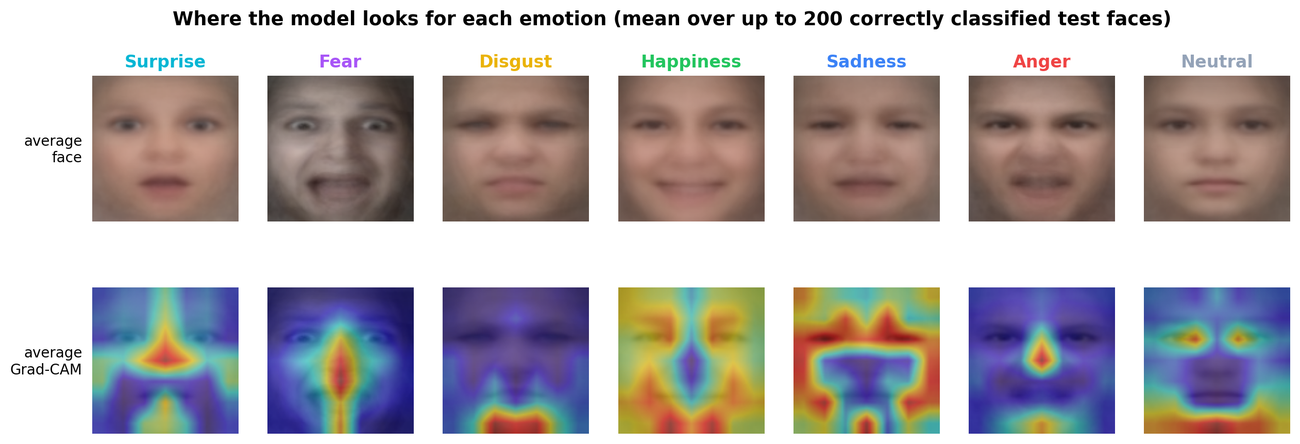

In [19]:
store = {}
def _h(m, i, o): store['f'] = o; o.retain_grad()
hook = model.features.register_forward_hook(_h)
cams = {c: [] for c in range(7)}
for c in range(7):
    idx = np.where((yte == c) & (pred == c))[0][:200]
    for i in range(0, len(idx), 64):
        x = to_tensor(Xte[idx[i:i + 64]]); model.zero_grad()
        out, _, _ = model(x); out[:, c].sum().backward()
        f = store['f']; w = f.grad.mean((2, 3), keepdim=True)
        cam = F.relu((w * f).sum(1, keepdim=True)); cam = F.interpolate(cam, (S, S), mode='bilinear', align_corners=False)[:, 0]
        cam = cam / (cam.flatten(1).max(1)[0].view(-1, 1, 1) + 1e-8); cams[c].append(cam.detach().cpu().numpy())
hook.remove()
fig, axs = plt.subplots(2, 7, figsize=(15, 4.9))
for c in range(7):
    idx = np.where((yte == c) & (pred == c))[0][:200]
    if len(idx) == 0: continue
    mean_face = Xte[idx].mean(0).astype(np.uint8); mcam = np.concatenate(cams[c]).mean(0); mcam = (mcam - mcam.min()) / (np.ptp(mcam) + 1e-8)
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * mcam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    axs[0, c].imshow(mean_face); axs[0, c].set_title(CLASS_NAMES[c], color=COLORS[c], fontsize=12, fontweight='bold')
    axs[1, c].imshow((.55 * mean_face + .45 * heat).astype(np.uint8))
for a in axs.flat: a.axis('off')
axs[0, 0].text(-8, S / 2, 'average\nface', ha='right', va='center', fontsize=10); axs[1, 0].text(-8, S / 2, 'average\nGrad-CAM', ha='right', va='center', fontsize=10)
fig.suptitle('Where the model looks for each emotion (mean over up to 200 correctly classified test faces)', fontweight='bold')
save(fig, 'gradcam_per_emotion.png')

## 9 · Summary

In [21]:
summary = {
    'clean': {'overall': round(clean_acc, 2), 'mean_class': round(clean_bacc, 2)},
    'flip_tta': {'overall': round(tta_acc, 2), 'mean_class': round(tta_bacc, 2)},
    'robustness': {k: [round(v, 2) for v in d['acc']] for k, d in robust.items() if k != 'Clean'},
    'robustness_levels': {k: v[2] for k, v in CORRUPTIONS.items()},
    'occlusion': {k: {'overall': round(occl_acc[k], 2), 'recall': dict(zip(CLASS_NAMES, [round(r, 1) for r in recall[k]]))} for k in occl},
    'calibration': {'temperature': round(T, 3), 'ece_before': round(ece_before, 2), 'ece_after': round(ece_after, 2)},
}
json.dump(summary, open(os.path.join(OUT, 'analysis_results.json'), 'w'), indent=2)
print(json.dumps(summary, indent=2))
import shutil; shutil.make_archive(os.path.join(OUT, 'analysis_figures'), 'zip', FIG); print(sorted(os.listdir(FIG)))

{
  "clean": {
    "overall": 91.07,
    "mean_class": 84.64
  },
  "flip_tta": {
    "overall": 91.1,
    "mean_class": 84.83
  },
  "robustness": {
    "Gaussian blur": [
      89.44,
      81.75,
      71.12
    ],
    "Low light": [
      90.35,
      89.02,
      83.44
    ],
    "Sensor noise": [
      90.22,
      85.92,
      76.5
    ],
    "JPEG compression": [
      90.38,
      89.05,
      81.88
    ],
    "Low resolution": [
      89.57,
      83.21,
      70.73
    ]
  },
  "occlusion": {
    "Clean": {
      "overall": 91.07
    },
    "Sunglasses (eyes covered)": {
      "overall": 85.1
    },
    "Face mask (mouth covered)": {
      "overall": 74.8
    }
  },
  "calibration": {
    "temperature": 1.552,
    "ece_before": 3.8,
    "ece_after": 1.4
  }
}
